# Анализ цен на дома


## 1. Overview

- TV - money spent on TV ad(*1000$)
- Radio - money spent on Radio ad(*1000$)
- Newspaper - money spent on Newspaper ad(*1000$)
- Sales - items sold(*1000)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
warnings.filterwarnings('ignore')

df = pd.read_csv('./advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [2]:
print('Количество записей\n', df.count())
print('\nХарактеристика\n', df.describe())
print('\nПропуски\n', df.isnull().sum())

Количество записей
 TV           200
Radio        200
Newspaper    200
Sales        200
dtype: int64

Характеристика
                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000

Пропуски
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## 2. EDA

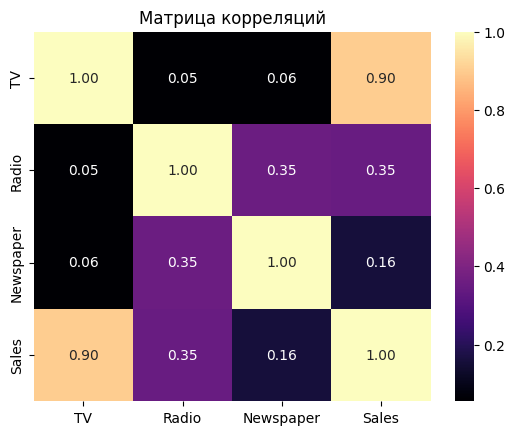

In [3]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='magma', annot=True, fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

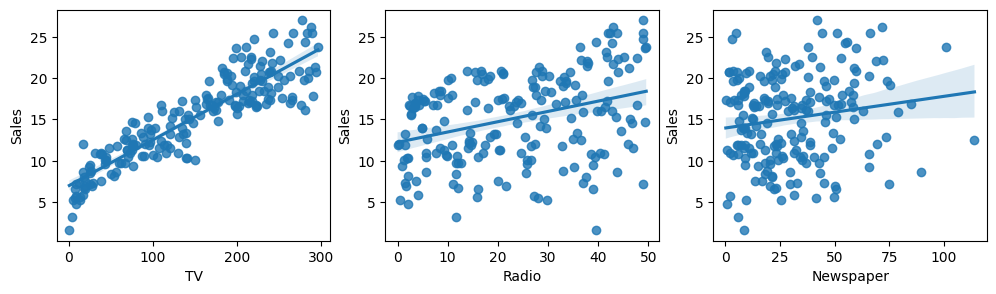

In [4]:
fig, axs = plt.subplots(1,3, figsize=(12,3))

sns.regplot(x='TV', y='Sales', data=df, ax=axs[0])

sns.regplot(x='Radio', y='Sales', data=df, ax=axs[1])

sns.regplot(x='Newspaper', y='Sales', data=df, ax=axs[2])


plt.show()

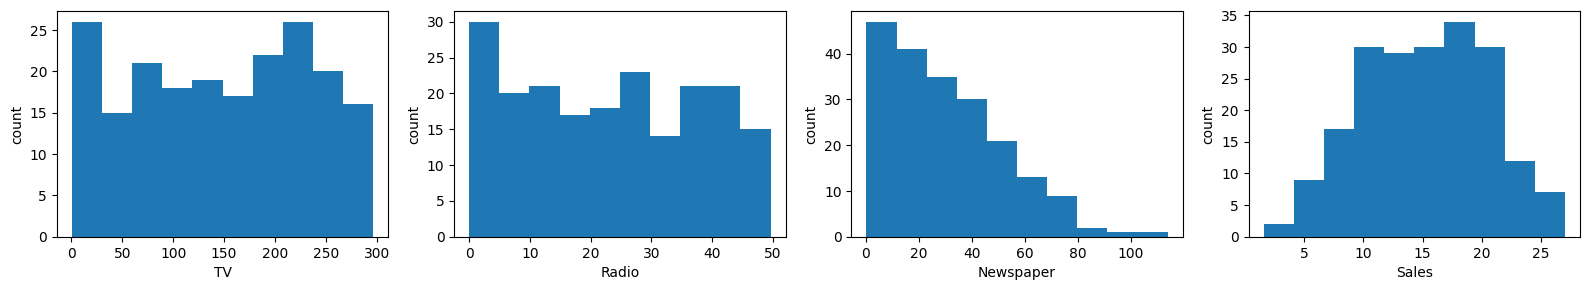

In [5]:
fig, axes = plt.subplots(1,4, figsize = (16, 3))

for i, ax in enumerate(axes):
    ax.hist(df.columns.tolist()[i], data=df)
    ax.set_xlabel(str(df.columns.tolist()[i]))
    ax.set_ylabel('count')

fig.tight_layout()
plt.show()

- В ходе EDA я понял что таргет сильно коррелириует с столбцом 'TV', а также в меньшей степени с остальными столбцами,
 значит можно использовать линейную регрессию

## 3. Обучение

In [6]:
X = df.drop('Sales', axis=1).values
y=df['Sales'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (150, 3)
Shape of X_test:  (50, 3)


- Выборку разделил на 25% test и 75% train. Модель нельзя обучать на одном наборе данных, потому что она подстроится под этот набор, и будет выдавать отличные результаты, а на новых данных может выдать плохой результат(и узнаем мы это тольк на этих данных)

In [7]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  0.8963539208098803
R2_score (train):  0.9276607239475623
R2_score (test):  0.9485618659991136
RMSE:  1.1825057943820385
MAPE:  0.07235694045616989


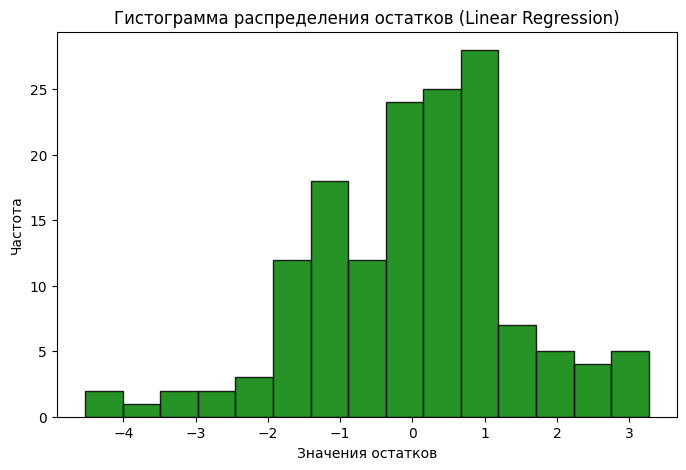

Статистика Колмогорова-Смирнова: 0.0659, P-значение: 5.1180e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


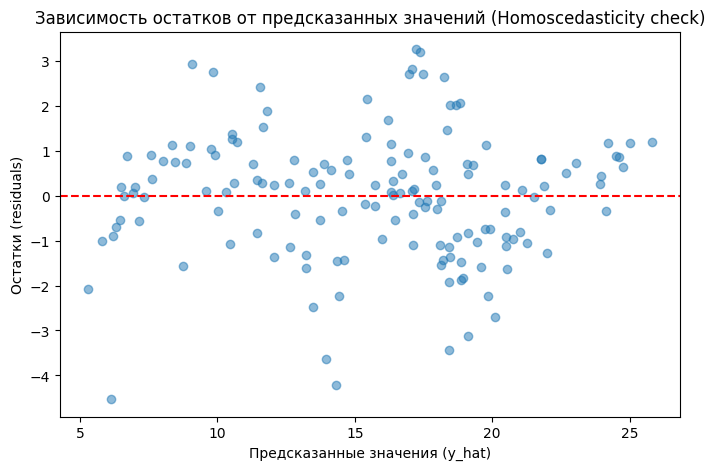

In [8]:
residuals = (y_train.ravel() - y_pred_linear_train.ravel())

def analyze_residuals(residuals, y_pred):

  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=15, color='green', alpha=0.85, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()


  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")


  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()
analyze_residuals(residuals, y_pred_linear_train)

In [9]:
ridge_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train.ravel())

best_ridge = ridge_grid.best_estimator_
print(f"Лучший параметр alpha для Ridge: {ridge_grid.best_params_['model__alpha']}")

y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)
cv_ridge = cross_val_score(estimator=best_ridge, X=X_train, y=y_train.ravel(), cv=10).mean()

print("Ridge Regression Results:")
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test): {r2_score_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAPE: {mape_ridge:.4f}")

Лучший параметр alpha для Ridge: 1.0
Ridge Regression Results:
R2 Score (train): 0.9276
R2 Score (test): 0.9487
RMSE: 1.18
MAPE: 0.0731


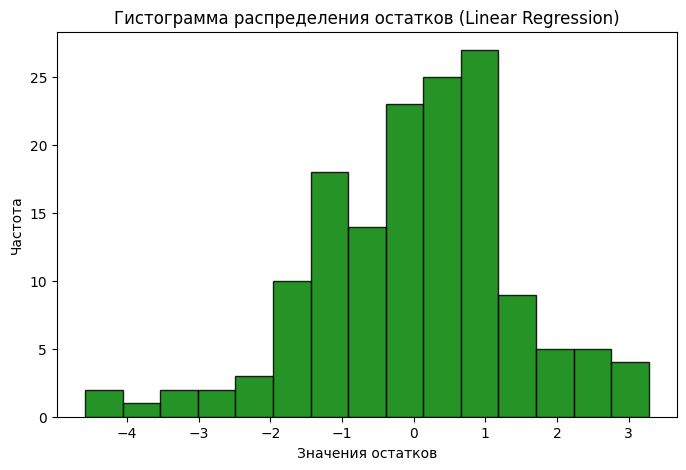

Статистика Колмогорова-Смирнова: 0.0616, P-значение: 5.9782e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


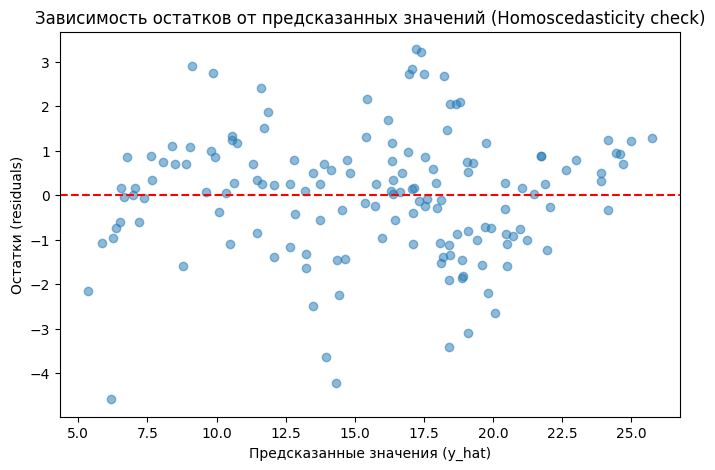

In [10]:
residuals_ridge = (y_train.ravel() - y_pred_ridge_train).ravel()
analyze_residuals(residuals_ridge, y_pred_ridge_train)

In [11]:
lasso_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Lasso(max_iter=5000))
]
lasso_pipe = Pipeline(lasso_steps)

lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train.ravel())

best_lasso = lasso_grid.best_estimator_
print(f"Лучший параметр alpha для Lasso: {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

r2_score_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_score_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)
cv_lasso = cross_val_score(estimator=best_lasso, X=X_train, y=y_train.ravel(), cv=10).mean()

print("Lasso Regression Results:")
print(f"R2 Score (train): {r2_score_lasso_train:.4f}")
print(f"R2 Score (test): {r2_score_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAPE: {mape_lasso:.4f}")

Лучший параметр alpha для Lasso: 0.1
Lasso Regression Results:
R2 Score (train): 0.9254
R2 Score (test): 0.9456
RMSE: 1.22
MAPE: 0.0780


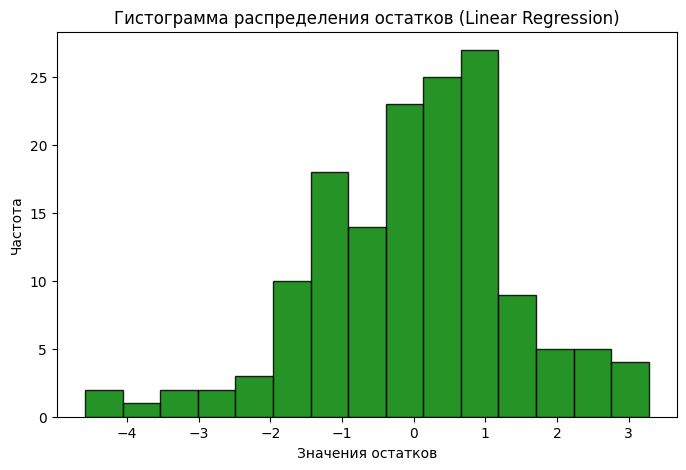

Статистика Колмогорова-Смирнова: 0.0616, P-значение: 5.9782e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


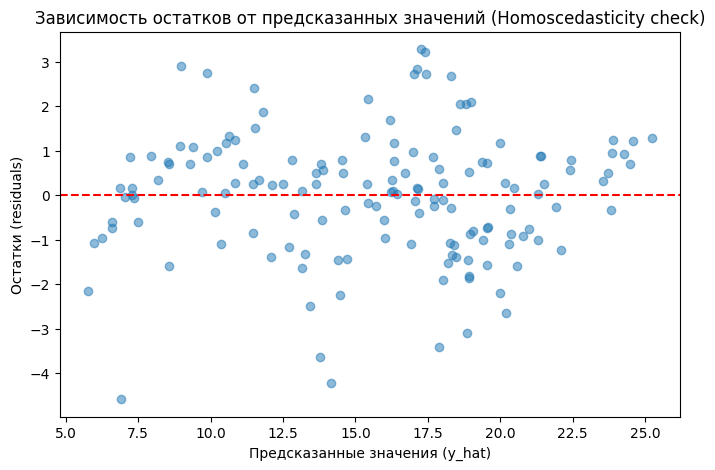

In [12]:
residuals_lasso = (y_train.ravel() - y_pred_lasso_train).ravel()
analyze_residuals(residuals_ridge, y_pred_lasso_train)

In [13]:
def add_const(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def gradient_descent(X, y, lr=0.01, iterations=5000):
    X_c = add_const(X)
    n, m = X_c.shape
    w = np.zeros(m)
    for k in range(iterations):
        grad = 2 / n * X_c.T @ (X_c @ w - y.ravel())
        w -= lr * grad
    return w


# Для ГС обязательно стандартизируем данные
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

# 1. Обучаем ручной Градиентный Спуск
w_gd = gradient_descent(X_train_scaled, y_train_scaled, lr=0.01, iterations=4000)
# Предсказание GD
y_pred_gd_scaled = add_const(X_test_scaled) @ w_gd
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled.reshape(-1, 1))

# 2. Обучаем OLS (МНК) из sklearn на тех же масштабированных данных
lr_scaled = LinearRegression(fit_intercept=True)
lr_scaled.fit(X_train_scaled, y_train_scaled.ravel())
w_ols = np.insert(lr_scaled.coef_, 0, lr_scaled.intercept_) # добавляем bias для красоты
y_pred_ols_scaled = lr_scaled.predict(X_test_scaled)
y_pred_ols = scaler_y.inverse_transform(y_pred_ols_scaled.reshape(-1, 1))

# Сравнение весов и результатов
print("Сравнение весов (w0, w1...):")
print(f"Градиентный спуск: \n{w_gd} ...") # Выводим первые 5 для компактности
print(f"Аналитический МНК: \n{w_ols} ...")

rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print(f"\nRMSE Градиентный спуск: {rmse_gd:.4f}")
print(f"RMSE МНК (LinearRegression): {rmse_ols:.4f}")

Сравнение весов (w0, w1...):
Градиентный спуск: 
[-4.71805754e-16  8.88098255e-01  2.84157914e-01  1.70542391e-02] ...
Аналитический МНК: 
[-5.19345423e-16  8.88098255e-01  2.84157914e-01  1.70542391e-02] ...

RMSE Градиентный спуск: 1.5505
RMSE МНК (LinearRegression): 1.5505


- Обучение: разделил данные на train/test, обучил LinearRegression, а для Ridge и Lasso подобрал alpha через GridSearchCV.

## 4. Итоги

In [14]:
models = [
    ('Linear Regression (Base)', rmse_linear, mape_linear, r2_score_linear_test),
    ('Ridge (GridSearchCV)', rmse_ridge, mape_ridge, r2_score_ridge_test),
    ('Lasso (GridSearchCV)', rmse_lasso, mape_lasso, r2_score_lasso_test),
]

predict_df = pd.DataFrame(data=models, columns=['Model', 'RMSE', 'MAPE', 'R2_Score(test)'])
display(predict_df)

,Model,RMSE,MAPE,R2_Score(test)
0,Linear Regression (Base),1.182506,0.072357,0.948562
1,Ridge (GridSearchCV),1.181295,0.073119,0.948667
2,Lasso (GridSearchCV),1.216250,0.077994,0.945584


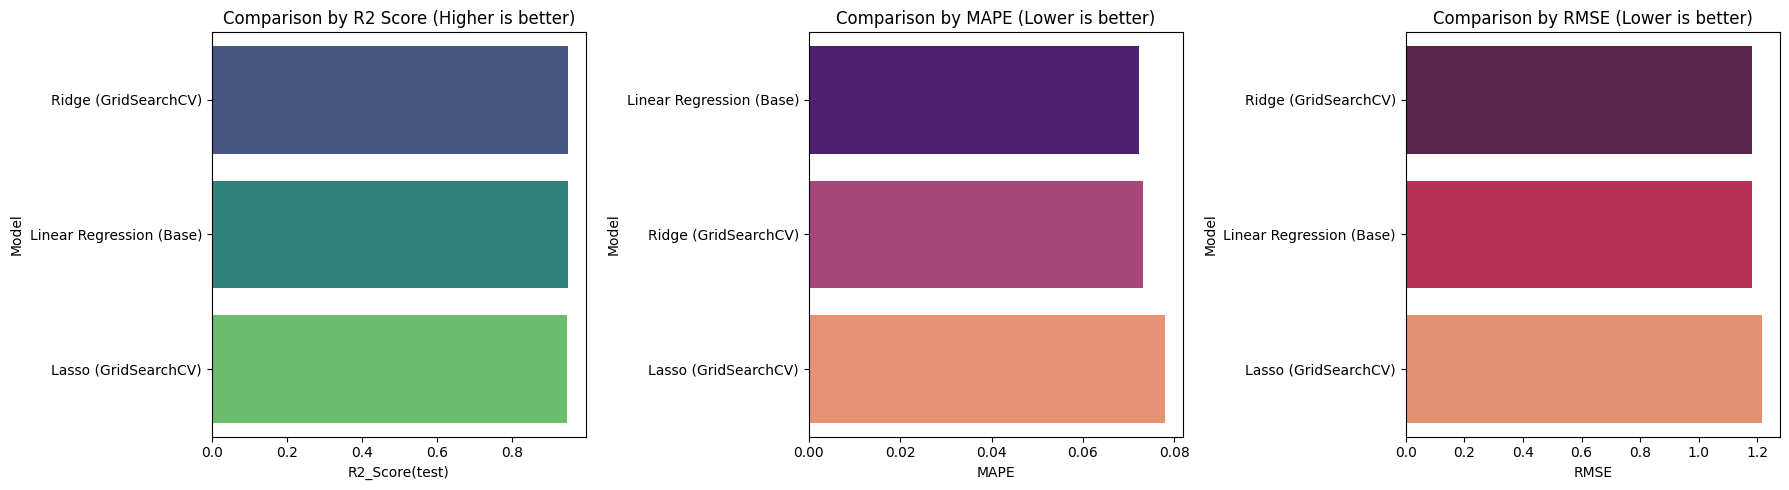

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma')
axes[1].set_title('Comparison by MAPE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket')
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

### Вывод

- для сравнения использовал метрики: MAPE(средний процент отклонения), RMSE(корень из среднего квадрата отклонения), MAE не использовал, потому что MAE прощает большие ошибки(MSE - нет)

- метрики считал на test выборке, потому что нужно увидеть как модель предсказывает незнакомые данные

- лучше всего справилась Ridge

- в результате получил что предсказанные значения отклоняются примерно на 7%

- модель не получилась, так как, по теореме Гаусса-маркова, остатки имеют нормальное распределение и не зависят от прогнозируемых значений